# Brain Tumor MRI Classification - Data Pipeline

In [1]:
# ==========================================
# Standard Library
# ==========================================
from pathlib import Path
import random
import warnings
import pickle

# ==========================================
# Data Handling
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# Visualization
# ==========================================
import matplotlib.pyplot as plt

# ==========================================
# TensorFlow
# ==========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

print("=" * 60)
print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("=" * 60)

TensorFlow : 2.21.0
NumPy      : 2.4.6


In [2]:
# ==========================================
# Project Configuration
# ==========================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration Loaded Successfully")

Configuration Loaded Successfully


In [3]:
# ==========================================
# Validate Dataset
# ==========================================

required_classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

assert TRAIN_DIR.exists(), f"Training folder not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Testing folder not found: {TEST_DIR}"

for class_name in required_classes:

    train_path = TRAIN_DIR / class_name
    test_path = TEST_DIR / class_name

    assert train_path.exists(), f"{class_name} missing in Training"
    assert test_path.exists(), f"{class_name} missing in Testing"

print("Dataset Validation Successful")

Dataset Validation Successful


In [4]:
# ==========================================
# Create Training Dataset
# ==========================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


In [5]:
# ==========================================
# Create Validation Dataset
# ==========================================

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [6]:
# ==========================================
# Create Testing Dataset
# ==========================================

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 1600 files belonging to 4 classes.


In [7]:
# ==========================================
# Class Names
# ==========================================

CLASS_NAMES = train_dataset.class_names

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)

print("Classes")

print("=" * 60)

for index, name in enumerate(CLASS_NAMES):

    print(f"{index} --> {name}")

print("=" * 60)
print("Number of Classes :", NUM_CLASSES)

Classes
0 --> glioma
1 --> meningioma
2 --> notumor
3 --> pituitary
Number of Classes : 4


In [8]:
# ==========================================
# Dataset Information
# ==========================================

print("=" * 60)

print("Training Batches   :", tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation Batches :", tf.data.experimental.cardinality(validation_dataset).numpy())

print("Testing Batches    :", tf.data.experimental.cardinality(test_dataset).numpy())

print("=" * 60)

Training Batches   : 140
Validation Batches : 35
Testing Batches    : 50


In [9]:
# ==========================================
# Optimize tf.data Pipeline
# ==========================================

train_dataset = train_dataset.cache()

train_dataset = train_dataset.shuffle(
    buffer_size=1000,
    seed=SEED
)

train_dataset = train_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_dataset.cache()

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

test_dataset = test_dataset.cache()

test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Dataset Pipeline Optimized Successfully")

Dataset Pipeline Optimized Successfully


In [10]:
# ==========================================
# Data Augmentation
# ==========================================

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

print(data_augmentation.summary())

Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


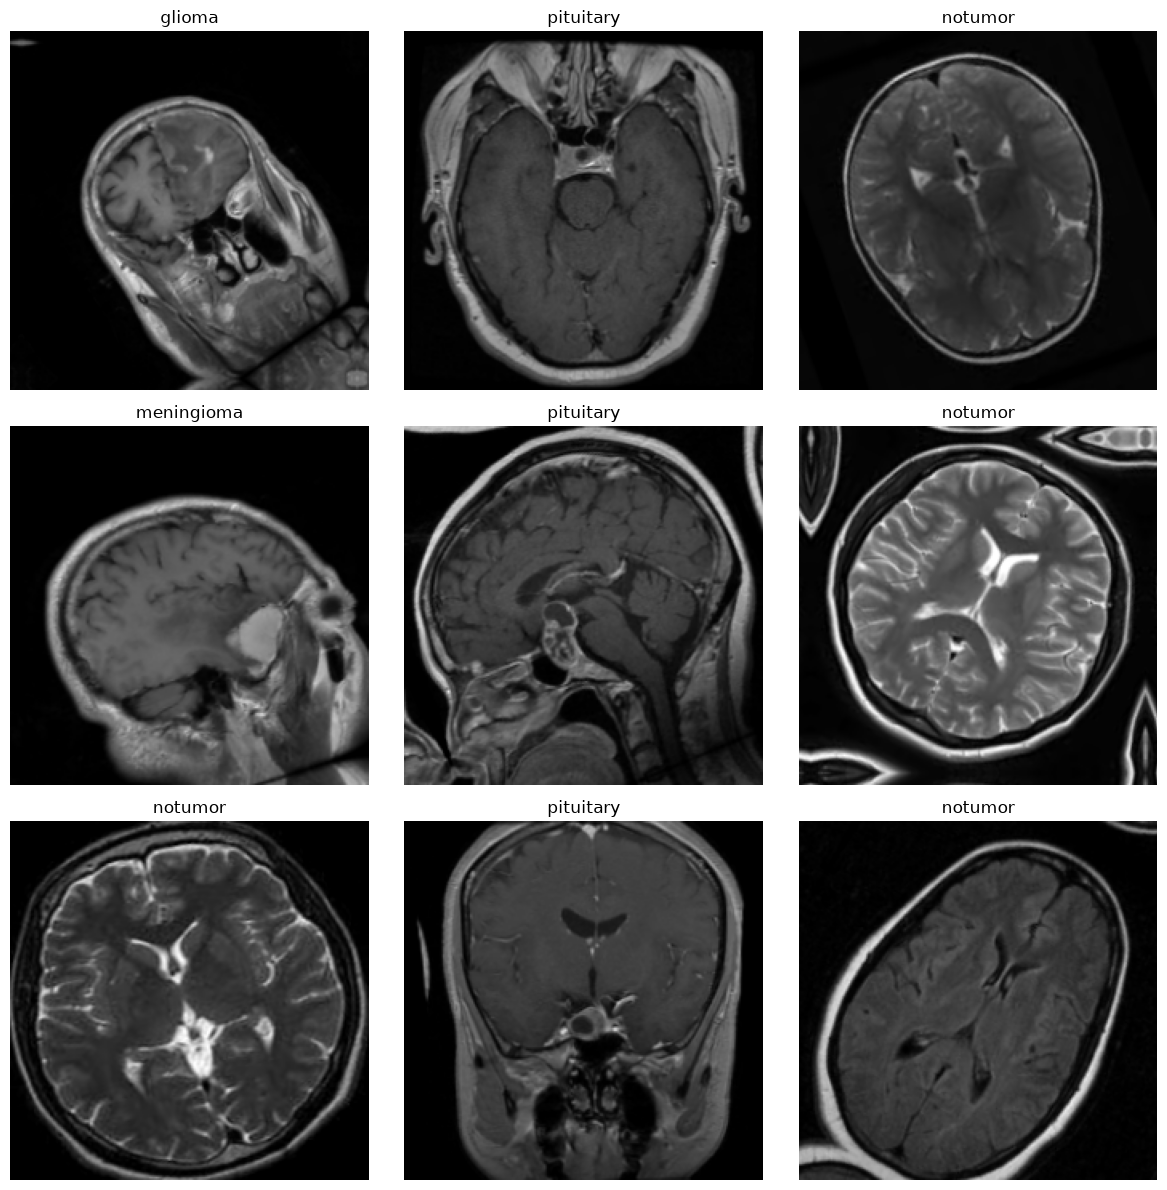

In [11]:
# ==========================================
# Visualize Augmented Images
# ==========================================

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.title(CLASS_NAMES[np.argmax(labels[i])])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
# ==========================================
# Save Class Names
# ==========================================

class_file = MODELS_DIR / "class_names.pkl"

with open(class_file, "wb") as file:
    pickle.dump(CLASS_NAMES, file)

print("Class Names Saved Successfully")
print(class_file)

Class Names Saved Successfully
c:\Users\SAINATH\github projects\brain-tumor-detector\models\class_names.pkl


In [13]:
# ==========================================
# Final Pipeline Summary
# ==========================================

print("=" * 60)

print("Data Pipeline Ready")

print("=" * 60)

print("Image Size       :", IMAGE_SIZE)
print("Batch Size       :", BATCH_SIZE)
print("Classes          :", NUM_CLASSES)
print("Training Dataset :", train_dataset)
print("Validation       :", validation_dataset)
print("Testing Dataset  :", test_dataset)

print("=" * 60)

Data Pipeline Ready
Image Size       : (224, 224)
Batch Size       : 32
Classes          : 4
Training Dataset : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>
Validation       : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>
Testing Dataset  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>


In [14]:
# Inspect One Training Batch

for images, labels in train_dataset.take(1):

    print(f"Image Batch Shape : {images.shape}")
    print(f"Label Batch Shape : {labels.shape}")

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32, 4)


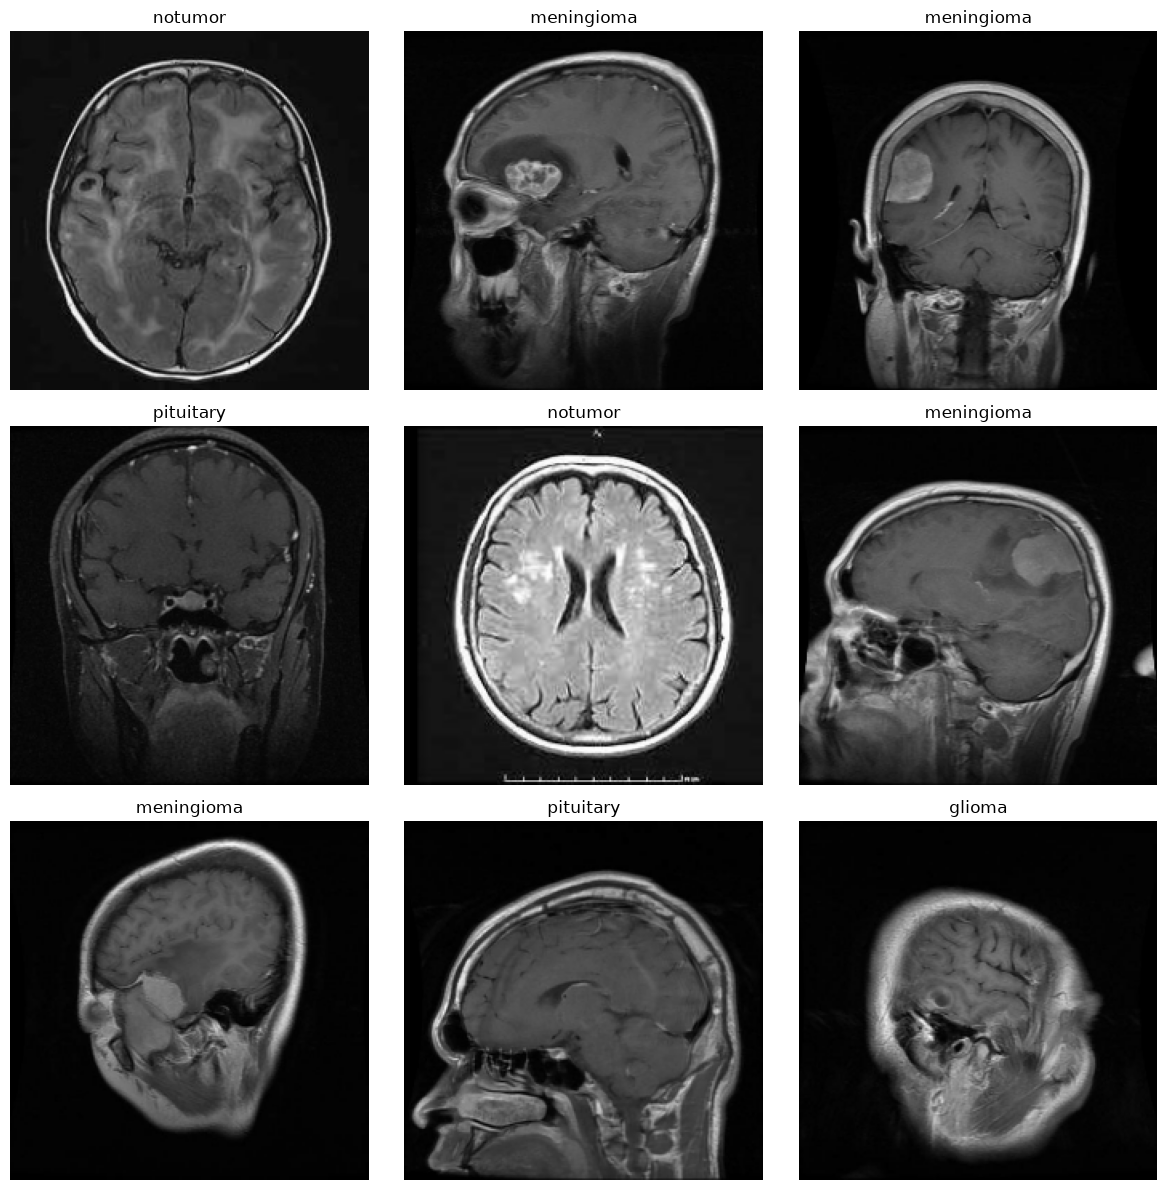

In [15]:
# Display One Batch

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(CLASS_NAMES[np.argmax(labels[i])])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [16]:
# Verify Image Properties

for images, labels in train_dataset.take(1):

    print("Image Data Type :", images.dtype)
    print("Label Data Type :", labels.dtype)

    print("Minimum Pixel Value :", tf.reduce_min(images).numpy())
    print("Maximum Pixel Value :", tf.reduce_max(images).numpy())

    break

Image Data Type : <dtype: 'float32'>
Label Data Type : <dtype: 'float32'>
Minimum Pixel Value : 0.0
Maximum Pixel Value : 255.0


In [17]:
# Dataset Cardinality

train_batches = tf.data.experimental.cardinality(train_dataset).numpy()

validation_batches = tf.data.experimental.cardinality(validation_dataset).numpy()

test_batches = tf.data.experimental.cardinality(test_dataset).numpy()

print(f"Training Batches   : {train_batches}")
print(f"Validation Batches : {validation_batches}")
print(f"Testing Batches    : {test_batches}")

Training Batches   : 140
Validation Batches : 35
Testing Batches    : 50


In [18]:
# Dataset Metadata

pipeline_info = {

    "image_height": IMAGE_HEIGHT,

    "image_width": IMAGE_WIDTH,

    "image_size": IMAGE_SIZE,

    "batch_size": BATCH_SIZE,

    "num_classes": NUM_CLASSES,

    "class_names": CLASS_NAMES,

    "train_batches": train_batches,

    "validation_batches": validation_batches,

    "test_batches": test_batches

}

pipeline_info

{'image_height': 224,
 'image_width': 224,
 'image_size': (224, 224),
 'batch_size': 32,
 'num_classes': 4,
 'class_names': ['glioma', 'meningioma', 'notumor', 'pituitary'],
 'train_batches': np.int64(140),
 'validation_batches': np.int64(35),
 'test_batches': np.int64(50)}

In [19]:
# Save Pipeline Information

pipeline_path = MODELS_DIR / "pipeline_info.pkl"

with open(pipeline_path, "wb") as file:

    pickle.dump(pipeline_info, file)

print("Pipeline information saved successfully.")

print(pipeline_path)

Pipeline information saved successfully.
c:\Users\SAINATH\github projects\brain-tumor-detector\models\pipeline_info.pkl


In [20]:
# Verify Saved Files

saved_files = list(MODELS_DIR.glob("*"))

print("Files inside models folder:\n")

for file in saved_files:

    print(file.name)

Files inside models folder:

class_names.pkl
pipeline_info.pkl


In [21]:
# Dataset Memory Performance

print("AUTOTUNE :", AUTOTUNE)

print("Cache Enabled : Yes")

print("Prefetch Enabled : Yes")

AUTOTUNE : -1
Cache Enabled : Yes
Prefetch Enabled : Yes


In [22]:
# Data Pipeline Summary

print("=" * 60)

print("Data Pipeline Completed Successfully")

print("=" * 60)

print(f"Training Classes      : {NUM_CLASSES}")

print(f"Class Names           : {CLASS_NAMES}")

print(f"Training Batches      : {train_batches}")

print(f"Validation Batches    : {validation_batches}")

print(f"Testing Batches       : {test_batches}")

print(f"Image Size            : {IMAGE_SIZE}")

print(f"Batch Size            : {BATCH_SIZE}")

print(f"Pipeline Saved        : pipeline_info.pkl")

print(f"Class Names Saved     : class_names.pkl")

print("=" * 60)

Data Pipeline Completed Successfully
Training Classes      : 4
Class Names           : ['glioma', 'meningioma', 'notumor', 'pituitary']
Training Batches      : 140
Validation Batches    : 35
Testing Batches       : 50
Image Size            : (224, 224)
Batch Size            : 32
Pipeline Saved        : pipeline_info.pkl
Class Names Saved     : class_names.pkl
